## Аналітичне дослідження клієнтської поведінки за допомогою лінійної регресії

In [294]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Проводимо EDA

In [295]:
df = pd.read_csv("project1_df.csv") # считуємо файл
df.head(3) # Ознайомлюємося із структурою даних

,CID,TID,Gender,Age Group,Purchase Date,Product Category,Discount Availed,Discount Name,Discount Amount (INR),Gross Amount,Net Amount,Purchase Method,Location
0,943146,5876328741,Female,25-45,30/08/2023 20:27:08,Electronics,Yes,FESTIVE50,64.30,725.304000,661.004000,Credit Card,Ahmedabad
1,180079,1018503182,Male,25-45,23/02/2024 09:33:46,Electronics,Yes,SEASONALOFFER21,175.19,4638.991875,4463.801875,Credit Card,Bangalore
2,337580,3814082218,Other,60 and above,06/03/2022 09:09:50,Clothing,Yes,SEASONALOFFER21,211.54,1986.372575,1774.832575,Credit Card,Delhi


In [296]:
df.shape  # дивимось розмірність

(55000, 13)

In [297]:
df.columns   # виводимо назви колонок

Index(['CID', 'TID', 'Gender', 'Age Group', 'Purchase Date',
       'Product Category', 'Discount Availed', 'Discount Name',
       'Discount Amount (INR)', 'Gross Amount', 'Net Amount',
       'Purchase Method', 'Location'],
      dtype='object')

In [292]:
df.info()   # перевіряємо типи даних

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CID                    55000 non-null  int64  
 1   TID                    55000 non-null  int64  
 2   Gender                 55000 non-null  object 
 3   Age Group              55000 non-null  object 
 4   Purchase Date          55000 non-null  object 
 5   Product Category       55000 non-null  object 
 6   Discount Availed       55000 non-null  object 
 7   Discount Name          27415 non-null  object 
 8   Discount Amount (INR)  55000 non-null  float64
 9   Gross Amount           55000 non-null  float64
 10  Net Amount             55000 non-null  float64
 11  Purchase Method        55000 non-null  object 
 12  Location               55000 non-null  object 
dtypes: float64(3), int64(2), object(8)
memory usage: 5.5+ MB


In [298]:
df.describe() # дивимось статистика по числових даних

,CID,TID,Discount Amount (INR),Gross Amount,Net Amount
count,55000.000000,5.500000e+04,55000.000000,55000.000000,55000.000000
mean,551245.593891,5.504740e+09,136.986796,3012.936606,2875.949810
std,260603.330337,2.594534e+09,165.375502,1718.431066,1726.127778
min,100009.000000,1.000163e+09,0.000000,136.454325,-351.119775
25%,323717.000000,3.252604e+09,0.000000,1562.111325,1429.551863
50%,550088.500000,5.498383e+09,0.000000,2954.266150,2814.910875
75%,776955.750000,7.747933e+09,274.115000,4342.221675,4211.407838
max,999996.000000,9.999393e+09,500.000000,8394.825600,8394.825600


In [299]:
df.isnull().sum() # перевіряємо наявності пропущених значень у кожній колонці

CID                          0
TID                          0
Gender                       0
Age Group                    0
Purchase Date                0
Product Category             0
Discount Availed             0
Discount Name            27585
Discount Amount (INR)        0
Gross Amount                 0
Net Amount                   0
Purchase Method              0
Location                     0
dtype: int64

In [300]:
df["Discount Name"] = df["Discount Name"].fillna("No Discount") # Запонюємо пропущені дані значенням "No Discount"

In [301]:
df.isnull().sum() # перевіряємо наявность пропущених значень у кожній колонці

CID                      0
TID                      0
Gender                   0
Age Group                0
Purchase Date            0
Product Category         0
Discount Availed         0
Discount Name            0
Discount Amount (INR)    0
Gross Amount             0
Net Amount               0
Purchase Method          0
Location                 0
dtype: int64

In [302]:
df.duplicated().sum()  # перевіряємо наявність дублікатів і загальну їх кількості

np.int64(0)

In [303]:
df['Age Group'].unique() # виводимо всі категорії по віку для подальшого використання

array(['25-45', '60 and above', '18-25', '45-60', 'under 18'],
      dtype=object)

#### Проаналізуємо розподі доходу по вікових групах та назвам знижок

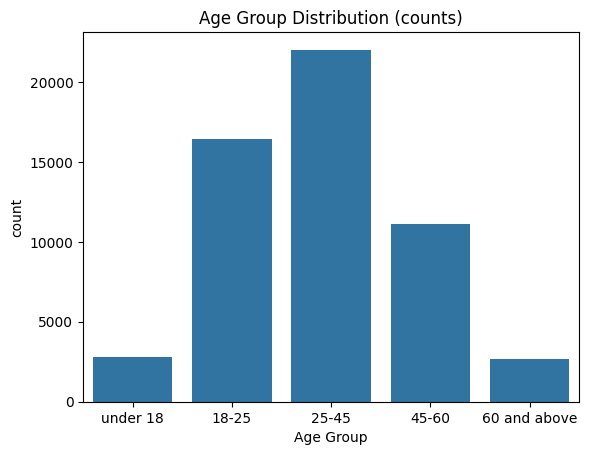

In [304]:
age_order = ['under 18', '18-25', '25-45', '45-60', '60 and above'] # визначаємо правильну послідовність вікових груп для осі X

sns.countplot(data=df, x='Age Group', order=age_order) # створюємо стовпчикову діаграму розподілу кількості клієнтів за віковими групами
plt.title("Age Group Distribution (counts)") # додаємо заголовок до графіка
plt.xticks(rotation=0) # показує положення надписів відносно осі Х
plt.show() # виводимо готовий графік

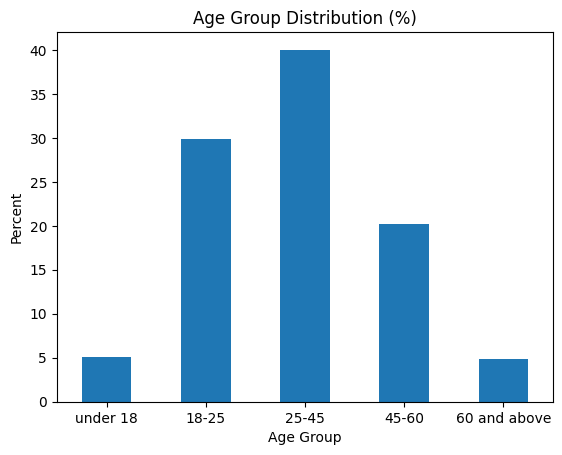

In [305]:
age_order = ['under 18', '18-25', '25-45', '45-60', '60 and above']

share = (
    df['Age Group']                         # обчислюємо частку кожної групи у %
    .value_counts(normalize=True)           # перетворюємо кількість у частки (від 0 до 1)
    .reindex(age_order)                     # сортуємо згідно з нашим списком age_order
    * 100
)

share.plot(kind='bar')                      # будуємо стовпчикову діаграму
plt.title("Age Group Distribution (%)")     # заголовок та підписи осей
plt.ylabel("Percent")                       # заголовок та підписи осей
plt.xticks(rotation=0)
plt.show()

In [306]:
df.groupby('Age Group')['Gross Amount'].mean().sort_index() # рахуємо середній чек для кожної вікової групи по Gross Amount

Age Group
18-25           2984.680912
25-45           3041.087756
45-60           2992.399477
60 and above    3026.011843
under 18        3026.510347
Name: Gross Amount, dtype: float64

In [307]:
df.groupby('Age Group')['Net Amount'].mean().sort_index() # рахуємо середній чек для кожної вікової групи по Net Amount

Age Group
18-25           2848.573795
25-45           2904.739214
45-60           2853.368124
60 and above    2886.688814
under 18        2889.693613
Name: Net Amount, dtype: float64

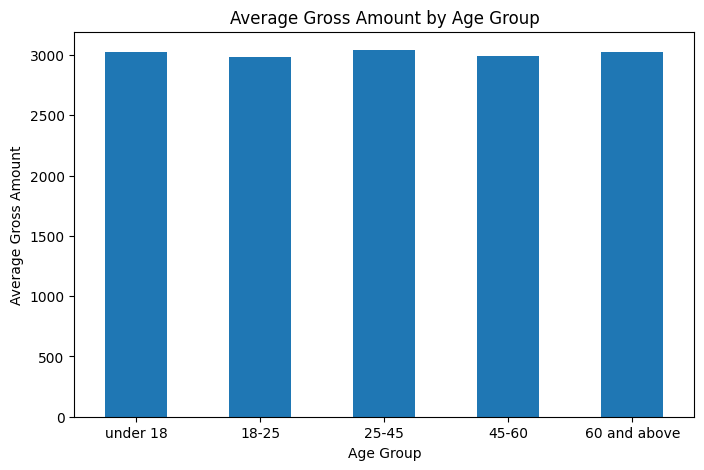

In [309]:
mean_values = (                                       # обчислюємо середнє значення покупок (Gross Amount) для кожної вікової групим
    df.groupby('Age Group')['Gross Amount']
      .mean()
      .reindex(age_order)
)

plt.figure(figsize=(8,5))                             # створюємо поле для графіка

mean_values.plot(kind='bar')                          # будуємо стовпчикову діаграму

plt.title("Average Gross Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Gross Amount")
plt.xticks(rotation=0)

plt.show()

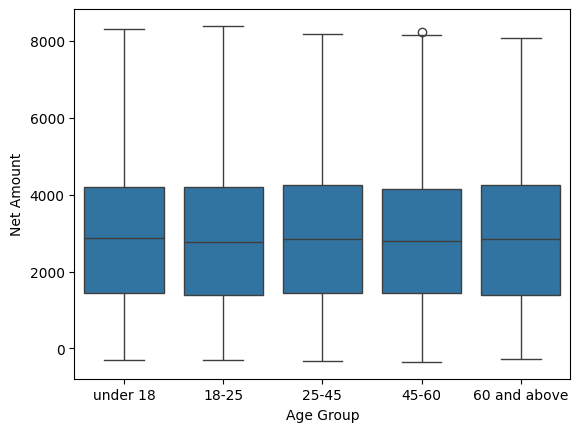

In [310]:
sns.boxplot(data=df, x='Age Group', y='Net Amount', order=age_order) # будуємо графіка "boxplot" для аналізу Net Amount за віком
plt.xticks(rotation=0)
plt.show()

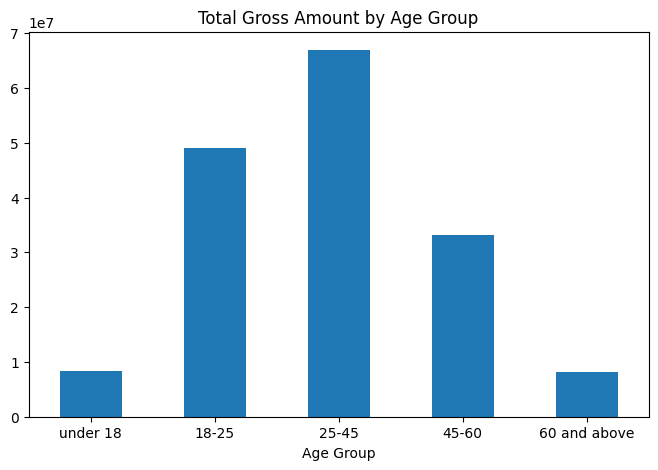

In [311]:
total_values = (                                  # обчислюємо cуму продажів (Gross Amount) для кожної вікової групи
    df.groupby('Age Group')['Gross Amount']
      .sum()
      .reindex(age_order)                         # впорядковуємо групи за нашим списком (under 18 -> 60+)
)

total_values.plot(kind='bar', figsize=(8,5))      # будуємо стовпчикову діаграму в сумі по категорії
plt.title("Total Gross Amount by Age Group")      # налаштовуємо візуалізацію
plt.xticks(rotation=0)
plt.show()

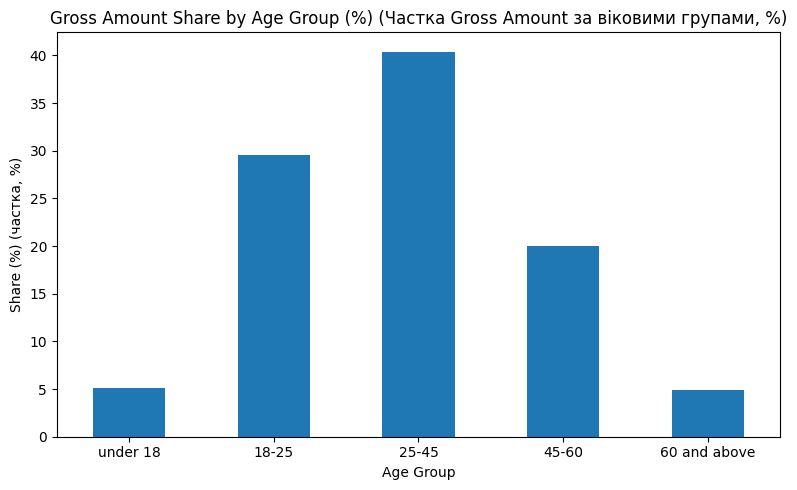

In [312]:
percent_values = total_values / total_values.sum() * 100   # обчислюємо у % продажів (Gross Amount) для кожної вікової групи

percent_values.plot(kind='bar', figsize=(8,5))
plt.title("Gross Amount Share by Age Group (%) (Частка Gross Amount за віковими групами, %)")
plt.ylabel("Share (%) (частка, %)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [313]:
df.columns

Index(['CID', 'TID', 'Gender', 'Age Group', 'Purchase Date',
       'Product Category', 'Discount Availed', 'Discount Name',
       'Discount Amount (INR)', 'Gross Amount', 'Net Amount',
       'Purchase Method', 'Location'],
      dtype='object')

In [314]:
# підготовка
df["discount_flag"] = df["Discount Availed"].astype(str).str.strip().str.lower().eq("yes") #  робимо прапорець для продажів із знижками

# Створюємо нову колонку "price_type" (тип ціни). Вона буде використовуватись для групування та легенди в графіках
df["price_type"] = df["discount_flag"].map({           
    True: "Discount (зі знижкою)",
    False: "Full price (повна ціна)"
})

df["Purchase Date"] = pd.to_datetime(df["Purchase Date"], errors="coerce")

df["order_month"] = df["Purchase Date"].dt.to_period("M").dt.to_timestamp() # аналізуємий період місяць 

C:\Users\svetl\AppData\Local\Temp\ipykernel_24952\3321427307.py:10: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Purchase Date"] = pd.to_datetime(df["Purchase Date"], errors="coerce")


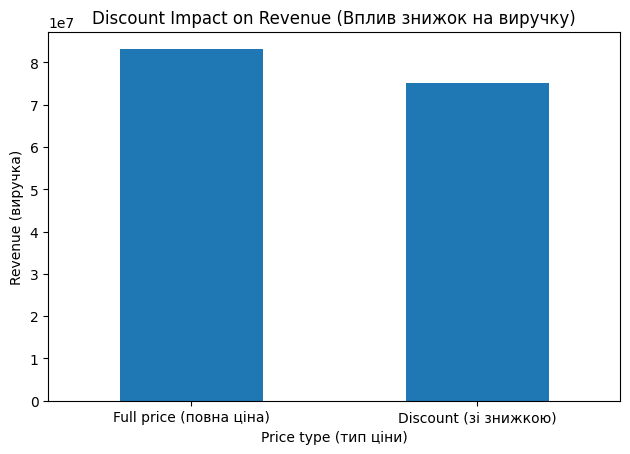

In [315]:
revenue_by_type = (                                           # групуємо дохід в залежності від наяності знижки
    df.groupby("price_type", dropna=False)["Net Amount"]   
      .sum()                                              
      .sort_values(ascending=False)                        
)

plt.figure()
revenue_by_type.plot(kind="bar")
plt.title("Discount Impact on Revenue (Вплив знижок на виручку)")
plt.xlabel("Price type (тип ціни)")
plt.ylabel("Revenue (виручка)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\svetl\AppData\Local\Temp\ipykernel_24952\105000985.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g:


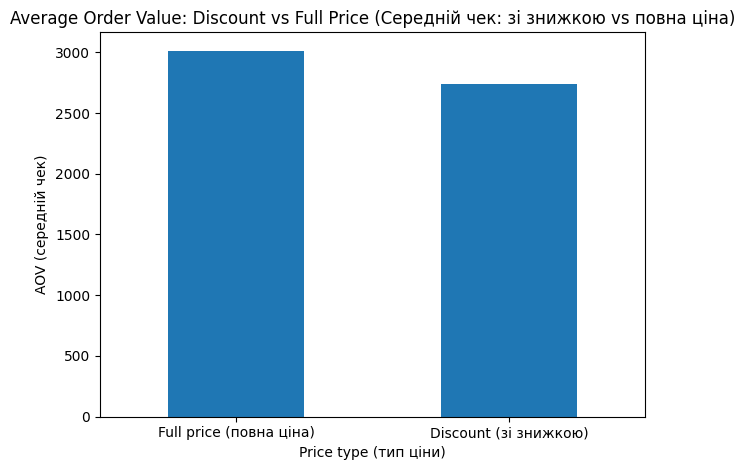

In [316]:
aov_by_type = (                                                  # рахуємо середній чек у розрізі price_type (ціни: зі знижкою / чи без)
    df.groupby("price_type", dropna=False)
      .apply(lambda g: 
             g["Net Amount"].sum() / g["TID"].nunique() 
             if g["TID"].nunique() else 0)
      .sort_values(ascending=False)
)

plt.figure()
aov_by_type.plot(kind="bar")
plt.title("Average Order Value: Discount vs Full Price (Середній чек: зі знижкою vs повна ціна)")
plt.xlabel("Price type (тип ціни)")
plt.ylabel("AOV (середній чек)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

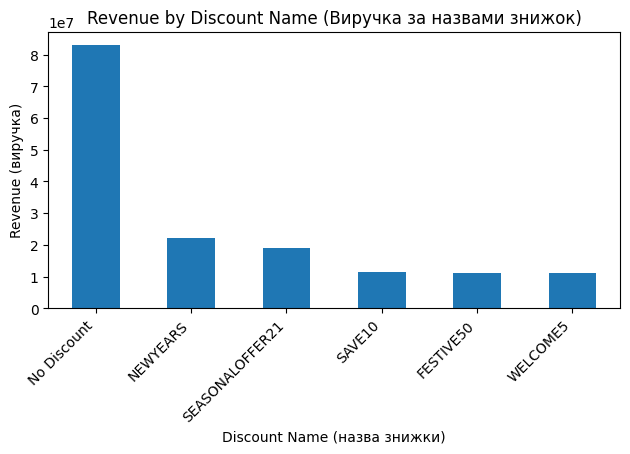

In [317]:
df["Net Amount"] = pd.to_numeric(df["Net Amount"], errors="coerce")       # рахуємо дохід в сумі грошей  по найменуванню зинжки, або її відсутності

rev_by_discount = (
    df.groupby("Discount Name")["Net Amount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure()
rev_by_discount.plot(kind="bar")
plt.title("Revenue by Discount Name (Виручка за назвами знижок)")
plt.xlabel("Discount Name (назва знижки)")
plt.ylabel("Revenue (виручка)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

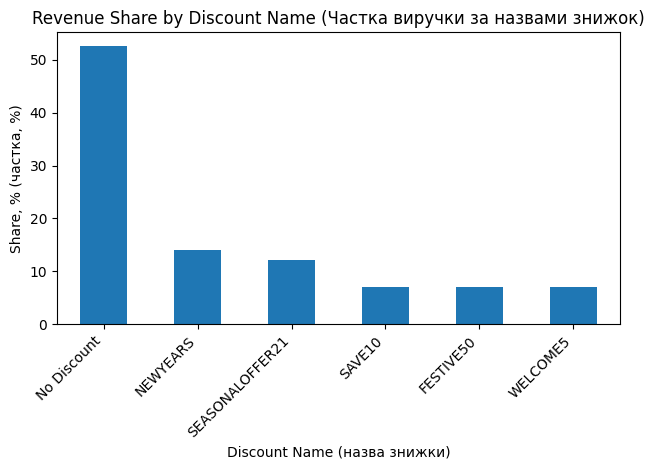

In [318]:
rev_share = (rev_by_discount / rev_by_discount.sum() * 100).round(2)            # рахуємо дохід в % по найменуванню зинжки, або її відсутності

plt.figure()
rev_share.sort_values(ascending=False).plot(kind="bar")
plt.title("Revenue Share by Discount Name (Частка виручки за назвами знижок)")
plt.xlabel("Discount Name (назва знижки)")
plt.ylabel("Share, % (частка, %)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

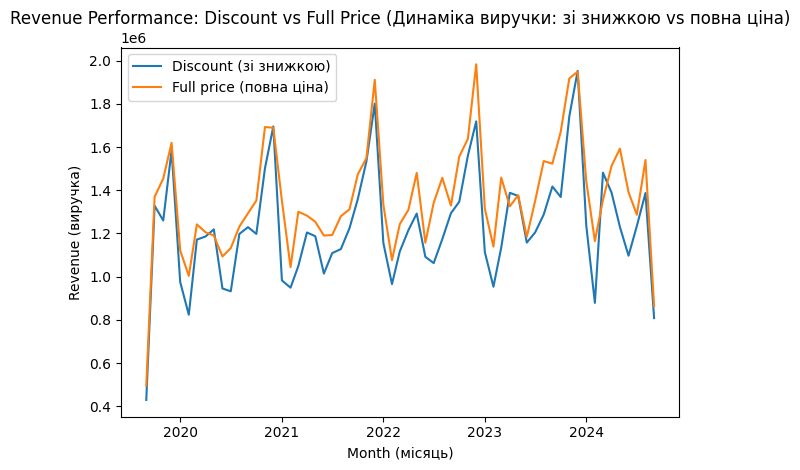

In [319]:
monthly_revenue = (                                                                     # виводимо тренд продажів по міцяціх
    df.groupby(["order_month", "price_type"], dropna=False)["Net Amount"]
      .sum()
      .reset_index()
      .pivot(index="order_month", columns="price_type", values="Net Amount")
      .sort_index()
)

plt.figure()
for col in monthly_revenue.columns:
    plt.plot(monthly_revenue.index, monthly_revenue[col], label=col)

plt.title("Revenue Performance: Discount vs Full Price (Динаміка виручки: зі знижкою vs повна ціна)")
plt.xlabel("Month (місяць)")
plt.ylabel("Revenue (виручка)")
plt.legend()
plt.tight_layout()
plt.show()

## Model

In [320]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [321]:
df.columns

Index(['CID', 'TID', 'Gender', 'Age Group', 'Purchase Date',
       'Product Category', 'Discount Availed', 'Discount Name',
       'Discount Amount (INR)', 'Gross Amount', 'Net Amount',
       'Purchase Method', 'Location', 'discount_flag', 'price_type',
       'order_month'],
      dtype='object')

In [322]:
required_columns = ["Gender", "Age Group", "Purchase Date",
       "Product Category", "Discount Name", "Discount Availed", "Discount Amount (INR)", "Purchase Method", "Location","Gross Amount"]                                  # готуємо df до побудови можелі. Позбавляємося ідентифікаторів та пустих значень
df = df[required_columns]
df.head()

,Gender,Age Group,Purchase Date,Product Category,Discount Name,Discount Availed,Discount Amount (INR),Purchase Method,Location,Gross Amount
0,Female,25-45,2023-08-30 20:27:08,Electronics,FESTIVE50,Yes,64.30,Credit Card,Ahmedabad,725.304000
1,Male,25-45,2024-02-23 09:33:46,Electronics,SEASONALOFFER21,Yes,175.19,Credit Card,Bangalore,4638.991875
2,Other,60 and above,2022-03-06 09:09:50,Clothing,SEASONALOFFER21,Yes,211.54,Credit Card,Delhi,1986.372575
3,Other,60 and above,2020-11-04 04:41:57,Sports & Fitness,No Discount,No,0.00,Debit Card,Delhi,5695.612650
4,Male,18-25,2022-05-31 17:00:32,Sports & Fitness,WELCOME5,Yes,439.92,Credit Card,Delhi,2292.651500


In [323]:
#  Ділимо дані на:
# X — ознаки (features), тобто вхідні дані для моделі, на основі яких алгоритм буде намагатися передбачити "Gross Amount".

X = df[["Gender", "Age Group", "Purchase Date",
       'Product Category', "Discount Name", "Discount Availed", "Purchase Method", "Location"]]
# target — назва цільової колонки (те, що ми хочемо передбачити)
target = "Gross Amount"

y = df[target]

In [324]:
# Розбиваємо дані на навчальну (train) і тестову (test) вибірки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                 # X — ознаки (features), y — ціль (target)
    test_size=0.25,       # 25% даних підуть у тестову вибірку,
                           # 75% залишаться для навчання моделі
    random_state=42       # фіксує випадковість розбиття,
                           # щоб результат був відтворюваним
)

In [325]:
X["Purchase Date"] = pd.to_datetime(X["Purchase Date"], errors="coerce")  # Перетворюємо колонку у формат datetime
X["purchase_year"] = X["Purchase Date"].dt.year # Створюємо нову ознаку: рік покупки (2022, 2023, 2024)
X["purchase_month"] = X["Purchase Date"].dt.month # Створюємо нову ознаку: місяць покупки від 1 до 12
X["purchase_dayofweek"] = X["Purchase Date"].dt.dayofweek # Створюємо нову ознаку: день тижня
X = X.drop(columns=["Purchase Date"]) # Видаляємо початкову колонку "Purchase Date"

C:\Users\svetl\AppData\Local\Temp\ipykernel_24952\2224223121.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Purchase Date"] = pd.to_datetime(X["Purchase Date"], errors="coerce")  # Перетворюємо колонку у формат datetime
C:\Users\svetl\AppData\Local\Temp\ipykernel_24952\2224223121.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["purchase_year"] = X["Purchase Date"].dt.year # Створюємо нову ознаку: рік покупки (2022, 2023, 2024)


In [326]:
# щоб можна було порахувати вплив "старіння", перетворюємо Age Group у впорядковану категорію
age_order = ['under 18', '18-25', '25-45', '45-60', '60 and above'] # вказуємо реальні категорії
X['Age Group'] = pd.Categorical(X['Age Group'], categories=age_order, ordered=True)
# Створюємо числовий стовпчик для регресії
X['Age_Numeric'] = X['Age Group'].cat.codes
# Ми застосували .cat.codes тільки до Age Group, тому що: це ordinal feature (порядкова ознака), вона має природний напрямок,ми хочемо перевірити “ефект старіння”

In [327]:
# Очистимо від NaN
data = pd.concat([X, y], axis=1).dropna()
X = data.drop(columns=["Gross Amount"])
y = data["Gross Amount"]
# Цей блок робимо, щоб X і y залишилися узгодженими та модель могла навчатися без помилок.

In [328]:
# робимо списки колонок для пайплайну - послідовність обробки даних
# "Age_Numeric" тепер у числових, щоб модель бачила лінійну залежність
categorical_features = ["Gender", "Product Category", "Discount Availed", "Purchase Method", "Location"]
numeric_features = ["Age_Numeric", "purchase_year", "purchase_month", "purchase_dayofweek"] 
# ми розділяємо ознаки на категоріальні та числові, щоб до кожного типу застосувати правильну обробку.

In [329]:
# Preprocess + model
preprocess = ColumnTransformer(                #дозволяє застосувати різні трансформації до різних колонок
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),  # перетворює текстові категорії на набір колонок 0/1.
        ("num", "passthrough", numeric_features),                               # нічого не робимо, просто передаємо числові колонки як є
    ]
)

model = Pipeline(steps=[
    ("preprocess", preprocess),                                                 # підготуває X (кодування категорій + передати числа)
    ("regressor", LinearRegression())                                           # навчаємо модель LinearRegression
])

In [330]:
# Проводимо тренування
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [331]:
# Отримуємо результати 
y_pred = model.predict(X_test)
print(f"R2: {r2_score(y_test, y_pred):.4f}")

R2: 0.0477


In [332]:
coefs = model.named_steps['regressor'].coef_                # Отримуємо коефіцієнт для Age_Numeric (він буде в кінці списку через passthrough)
feature_names = model.named_steps["preprocess"].get_feature_names_out()
age_impact = coefs[-4] # Останні 4 — це наші numeric_features, Age_Numeric — перший серед них

print(f"коефіцієнти моделі: {coefs}")
print(f"\nКоефіцієнт впливу вікової групи: {age_impact:.2f}")
#print(f"Назви ознак в можелі {feature_names}")
print(f"При переході в наступну вікову групу, витрати зміняться на: {age_impact:.2f}")
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


коефіцієнти моделі: [-2.14493276e+01  5.23597847e-01  2.09257298e+01  1.78632397e+01
 -2.46267342e+01 -2.87454865e+01 -2.67350349e+01  2.13872906e+00
 -3.14828449e+01  1.02435807e-01  4.59208924e+01  4.55648035e+01
  2.94697986e+00 -2.94697986e+00 -7.13525340e+01  1.03429404e+01
  1.04521039e+01 -4.86953450e+01 -1.48796136e+01 -4.60524577e+00
  2.72528758e+01  9.14848182e+01  2.48312781e-01 -1.92137080e+01
  3.15053027e+01 -7.67670428e+01  6.78218730e+00 -1.59133578e+01
  2.44558567e+01 -9.25184631e+00  1.72341037e+01 -9.45744974e+00
  4.67912901e+01  2.39885586e+01  4.86483925e+00 -2.52670466e+01
  1.96503474e+00  1.15179677e+02  1.06784880e+02 -1.23175266e+00]

Коефіцієнт впливу вікової групи: 1.97
При переході в наступну вікову групу, витрати зміняться на: 1.97
R2: 0.047745928889017186
MAE: 1420.459707810365
